In [1]:
import os
import pickle
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
# from acc_features import GenerateFeatures
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from xgboost import XGBClassifier
from sklearn.preprocessing import scale # Data scaling
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler




In [2]:
# features.drop(['center_time', 'start_time', 'end_time', 'gyr_x_permutation_entropy', 'gyr_y_permutation_entropy', 'gyr_z_permutation_entropy', 'gyr_mag_permutation_entropy', 'gyr_x_spectral_entropy', 'gyr_y_spectral_entropy', 'gyr_z_spectral_entropy', 'gyr_mag_spectral_entropy'], axis=1, inplace=True)
# features = pd.read_csv('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/feature_based_data/three_class_up_1s_ag.csv')
features = pd.read_csv('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/features_data_main/three_class_raw_2s_yo_0.8.csv')
features.drop(['center_time', 'start_time', 'end_time'], axis= 1, inplace=True)
# df = features.loc[:, ~features.columns.str.contains('_energy$|_min$|_max$|_entropy$')]  # Drops columns starting with 'user'
features.head()


,acc_x_permutation_entropy,acc_x_spectral_entropy,acc_x_mean,acc_x_std,acc_x_range,acc_x_rms,acc_x_var,acc_x_min,acc_x_max,acc_x_time_energy,...,gyr_mag_std,gyr_mag_range,gyr_mag_rms,gyr_mag_var,gyr_mag_min,gyr_mag_max,gyr_mag_time_energy,gyr_mag_spectral_energy,label,experiment_id
0,0.837517,0.656083,1.027208,1.005637,5.349532,1.437520,1.011306,-1.100002,4.249530,243.842623,...,1.742222,7.487364,3.090512,3.035336,0.262540,7.749904,1127.049263,132991.813018,pre-void,1
1,0.856472,0.634105,1.049054,0.936724,5.349532,1.406402,0.877451,-1.100002,4.249530,233.399948,...,1.787973,7.614706,2.800308,3.196848,0.135198,7.749904,925.323664,109188.192384,pre-void,1
2,0.866184,0.638264,0.996176,0.888607,5.349532,1.334912,0.789622,-1.100002,4.249530,210.274765,...,1.741895,7.657108,2.450640,3.034198,0.092797,7.749904,708.665105,83622.482415,pre-void,1
3,0.878813,0.663285,0.929198,0.584101,3.553001,1.097535,0.341174,-0.289933,3.263068,142.140853,...,1.502970,7.657108,1.939446,2.258920,0.092797,7.749904,443.851412,52374.466635,pre-void,1
4,0.905723,0.782317,0.762776,0.265824,1.479456,0.807768,0.070662,-0.132898,1.346558,76.993792,...,0.436316,3.250805,0.733959,0.190372,0.076565,3.327370,63.566144,7500.804959,pre-void,1


View label distribution

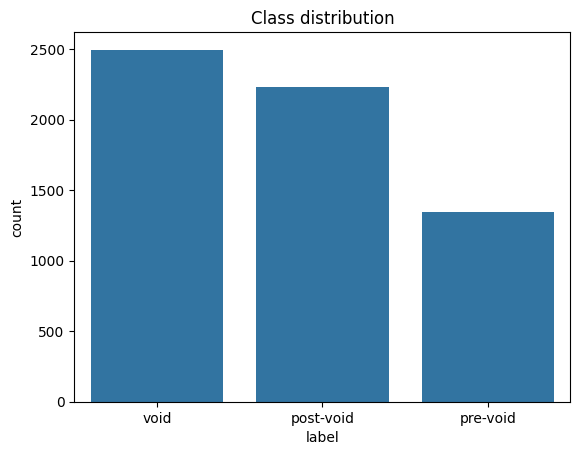

In [3]:
plt.figure()
sns.countplot(x = 'label',
              data = features,
              order = features.label.value_counts().index)
plt.title('Class distribution')
plt.show()

In [4]:
features.label.value_counts()

label
void         2497
post-void    2235
pre-void     1347
Name: count, dtype: int64

In [5]:
X = features.drop(columns=['label', 'experiment_id'])
y = features['label']
groups = features['experiment_id']

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]



PCA

In [6]:
scaler = StandardScaler()
pca = PCA()

In [7]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
pca.fit(X_train_scaled)

PCA()

In [8]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

In [9]:
pca_final = PCA(n_components=3)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)



In [10]:
# Encode string labels to integers
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)


# Now train XGBoost
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="multi:softprob",
    eval_metric='mlogloss',
    # reg_alpha=0.1,   # L1 regularization
    # reg_lambda=1.0,  # L2 regularization
    # early_stopping_rounds=10,
    # scale_pos_weight=1.27,
    verbosity=0, 
    # booster=True
)

eval_set = [(X_train_pca, y_train_encoded), (X_test_pca, y_test_encoded)]
model.fit(X_train_pca, y_train_encoded, eval_set=eval_set, verbose=False)  # Use encoded labels

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [26]:
# Classification report
y_pred = label_encoder.inverse_transform(model.predict(X_test_pca))
y_pred_prob = model.predict_proba(X_test_pca)
y_pred_labels = label_encoder.inverse_transform(np.argmax(y_pred_prob, axis=1))




In [ ]:
target_order = ['pre-void', 'void', 'post-void']
report = classification_report(y_test, y_pred, labels=target_order)
print(report)

              precision    recall  f1-score   support

    pre-void       0.25      0.34      0.29       295
        void       0.60      0.63      0.62       641
   post-void       0.58      0.47      0.52       700

    accuracy                           0.51      1636
   macro avg       0.48      0.48      0.48      1636
weighted avg       0.53      0.51      0.52      1636



In [12]:
acc_score = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_prob, multi_class='ovr', average='macro')
print(f"The score on the training set is accuracy: {acc_score:0.4f} and the AUC is {auc_score: 0.4f}")

The score on the training set is accuracy: 0.5104 and the AUC is  0.6865


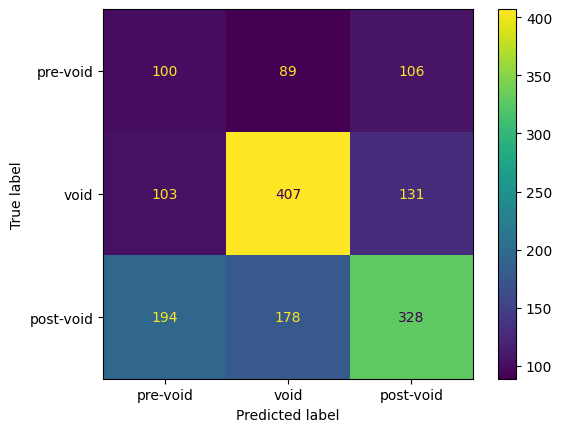

In [27]:
# Confusion matrix
labels = ['pre-void', 'void', 'post-void']

cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = labels)
cm_display.plot()
plt.show()
# plt.savefig('model_plots/unsampled_2secs/cm_2sec.png')


In [29]:
print("Accuracy: ", accuracy_score(y_test, y_pred))

Accuracy:  0.5103911980440098


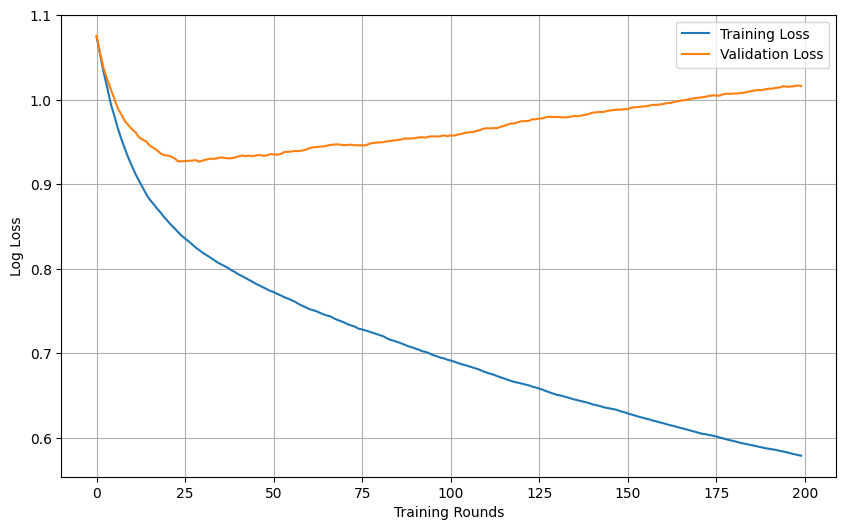

In [14]:
# Retrieve the evaluation results
results = model.evals_result()
train_loss = results['validation_0']['mlogloss']
test_loss = results['validation_1']['mlogloss']

# Plot the loss function
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss')
plt.plot(test_loss, label='Validation Loss')
plt.xlabel('Training Rounds')
plt.ylabel('Log Loss')
# plt.title('Loss')
plt.legend()
plt.grid(True)
# plt.savefig('model_plots/unsampled_2secs/unsampled_loss_2sec.png')

In [15]:
report_dict = classification_report(y_test, y_pred, output_dict=True)
report_dict

{'post-void': {'precision': 0.5805309734513274,
  'recall': 0.4685714285714286,
  'f1-score': 0.5185770750988142,
  'support': 700.0},
 'pre-void': {'precision': 0.2518891687657431,
  'recall': 0.3389830508474576,
  'f1-score': 0.28901734104046245,
  'support': 295.0},
 'void': {'precision': 0.6038575667655787,
  'recall': 0.6349453978159126,
  'f1-score': 0.6190114068441065,
  'support': 641.0},
 'accuracy': 0.5103911980440098,
 'macro avg': {'precision': 0.4787592363275497,
  'recall': 0.4808332924115996,
  'f1-score': 0.47553527432779436,
  'support': 1636.0},
 'weighted avg': {'precision': 0.5304105663194129,
  'recall': 0.5103911980440098,
  'f1-score': 0.5165344620801825,
  'support': 1636.0}}

In [16]:
params = {   "n_estimators":200,
    "max_depth":5,
    "learning_rate":0.1,
    "subsample":0.8,
    "colsample_bytree":0.8,
    "random_state":42,
    "objective":"multi:softprob",
    "eval_metric":'mlogloss',
    "reg_alpha":0.1,   # L1 regularization
    "reg_lambda":1.0,  # L2 regularization
    # early_stopping_rounds=10,
    # scale_pos_weight=1.27,
    "verbosity":0, 
    }

In [17]:
import mlflow
import mlflow.xgboost
from mlflow.models.signature import infer_signature
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import os

def log_experiment_run(
    model,
    X_test,
    report_dict,
    params,
    experiment_name="Earlier Results",
    model_name="XGBoost"
):

    # Set experiment
    mlflow.set_tracking_uri("http://127.0.0.1:5000")
    mlflow.set_experiment(experiment_name)

    run_name = f"{params.get('window_size', 'NA')}s_win_{int(params.get('overlap', 0.0) * 100)}%_overlap_ag"
    # run_name = f"{params.get('window_size', 'NA')}s_win_{int(params.get('overlap', 0.0) * 100)}%_overlap_{params.get('smote')}" # with smote
    
    del params['window_size']
    del params['overlap']
    del params['smote']

    with mlflow.start_run(run_name=run_name):
        # Log parameters
        mlflow.log_params(params)

        
        mlflow.log_metrics({
            "accuracy": report_dict.get("accuracy", 0.0),
            "recall_pre_void": report_dict.get("pre-void", {}).get("recall", 0.0),
            "recall_void": report_dict.get("void", {}).get("recall", 0.0),
            "recall_post_void": report_dict.get("post-void", {}).get("recall", 0.0),
            "f1_score_macro": report_dict.get("macro avg", {}).get("f1-score", 0.0)
        })

        # Log model with signature
        # input_example = X_test.iloc[:1]
        input_example = X_test[:1]
        signature = infer_signature(X_test, model.predict(X_test))

        try:
            mlflow.xgboost.log_model(
                xgb_model=model,
                artifact_path=model_name,
                input_example=input_example,
                signature=signature
            )
        except Exception as e:
            print("Error logging model:", e)

In [18]:
from sklearn.metrics import classification_report

# # Example parameters
# params['window_size'] = 2
# params['overlap'] = 0.8
# params['smote'] = 'smote'
# params['exp_name'] = '2s_window_ag'


# # y_pred = model.predict(X_test)
# report_dict = classification_report(y_test, y_pred, output_dict=True)

# log_experiment_run(model, X_test, report_dict, params)

### SHAP Analysis

In [19]:
# import shap

# # Create an explainer
# explainer = shap.TreeExplainer(model)

# # Calculate SHAP values for the test set
# shap_values = explainer.shap_values(X_test)

# # Plot SHAP summary plot
# shap.summary_plot(shap_values, X_test, feature_names=X.columns, plot_type="bar",max_display=30)

In [20]:
# interaction_values = explainer.shap_interaction_values(X_test)

# # Plot interactions for all features
# shap.summary_plot(interaction_values, X_test)

## Feature Importance

In [21]:
# feature_importances = pd.Series(model.feature_importances_, index=X_train.columns)

In [22]:
# fig, ax = plt.subplots(figsize=(15, 7))
# feature_importances.plot.bar(ax=ax)
# ax.set_title("Feature importance - XGBoost Clf")
# ax.set_ylabel("Mean decrease in impurity")
# fig.tight_layout()
# plt.show()

In [23]:
# # Sort features by importance (descending order)
# feature_importances_sorted = feature_importances.sort_values(ascending=False)

# # Display top features
# print("Top 20 most important features:")
# print(feature_importances_sorted.head(20))

# # Plot sorted features
# fig, ax = plt.subplots(figsize=(15, 7))
# feature_importances_sorted.plot.bar(ax=ax)
# ax.set_title("Feature importance - XGBoost Clf (Sorted)")
# ax.set_ylabel("Mean decrease in impurity")
# fig.tight_layout()
# plt.show()

Cross validation using GroupKFold

In [24]:
# from sklearn.model_selection import GroupKFold
# from sklearn.metrics import accuracy_score, classification_report
# import numpy as np

# # Setup GroupKFold
# gkf = GroupKFold(n_splits=5)  # 5-fold cross-validation
# scores = []
# auc_scores = []

# # Perform cross-validation
# for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
#     print(f"Fold {fold + 1}")
    
#     # Split data
#     X_train_fold = X.iloc[train_idx]
#     X_val_fold = X.iloc[val_idx]
#     y_train_fold = y.iloc[train_idx]
#     y_val_fold = y.iloc[val_idx]
    
#     # Encode labels
#     y_train_encoded = label_encoder.fit_transform(y_train_fold)
#     y_test_encoded = label_encoder.transform(y_val_fold)
    
#     # Train model
#     model = XGBClassifier(
#         n_estimators=200,
#         max_depth=5,
#         learning_rate=0.1,
#         subsample=0.8,
#         colsample_bytree=0.8,
#         objective="multi:softprob",
#         eval_metric='mlogloss',
#         reg_alpha=0.1,   # L1 regularization
#         reg_lambda=1.0,  # L2 regularization
#         verbosity=0
#     )
#     model.fit(X_train_fold, y_train_encoded)
    
#     # Evaluate
#     y_pred = model.predict(X_val_fold)
#     y_pred_prob = model.predict_proba(X_val_fold)
#     y_pred_labels = label_encoder.inverse_transform(np.argmax(y_pred_prob, axis=1))
    
#     score = accuracy_score(y_test_encoded, y_pred)
#     scores.append(score)
    
#     auc_score = roc_auc_score(y_test_encoded, y_pred_prob, multi_class='ovr', average='macro')
#     auc_scores.append(auc_score)
    
    
#     print(f"Validation Accuracy: {acc_score:.4f}")
#     print(f"Unique groups in train: {X_train.index.map(lambda x: groups.iloc[x]).nunique()}")
#     print(f"Unique groups in val: {X_test.index.map(lambda x: groups.iloc[x]).nunique()}")
#     print("-" * 50)

# # Overall results
# print(f"Mean CV Score: {np.mean(scores):.4f} (+/- {np.std(scores) * 2:.4f})")
# print(f"Mean ROC_AUC Score: {np.mean(auc_scores)}")